<a href="https://colab.research.google.com/github/Narges-Sefid/MachineLearning/blob/main/ML_Assignment3_Narges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
import pandas as pd
from sklearn import datasets
diabetes = datasets.load_diabetes()
ddf = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
ddf["target"] = diabetes.target
ddf.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Link for more info:
[link text](https://https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset)

# Explanatory Data Analysis

In [ ]:
ddf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [ ]:
ddf.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [ ]:
ddf.target

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


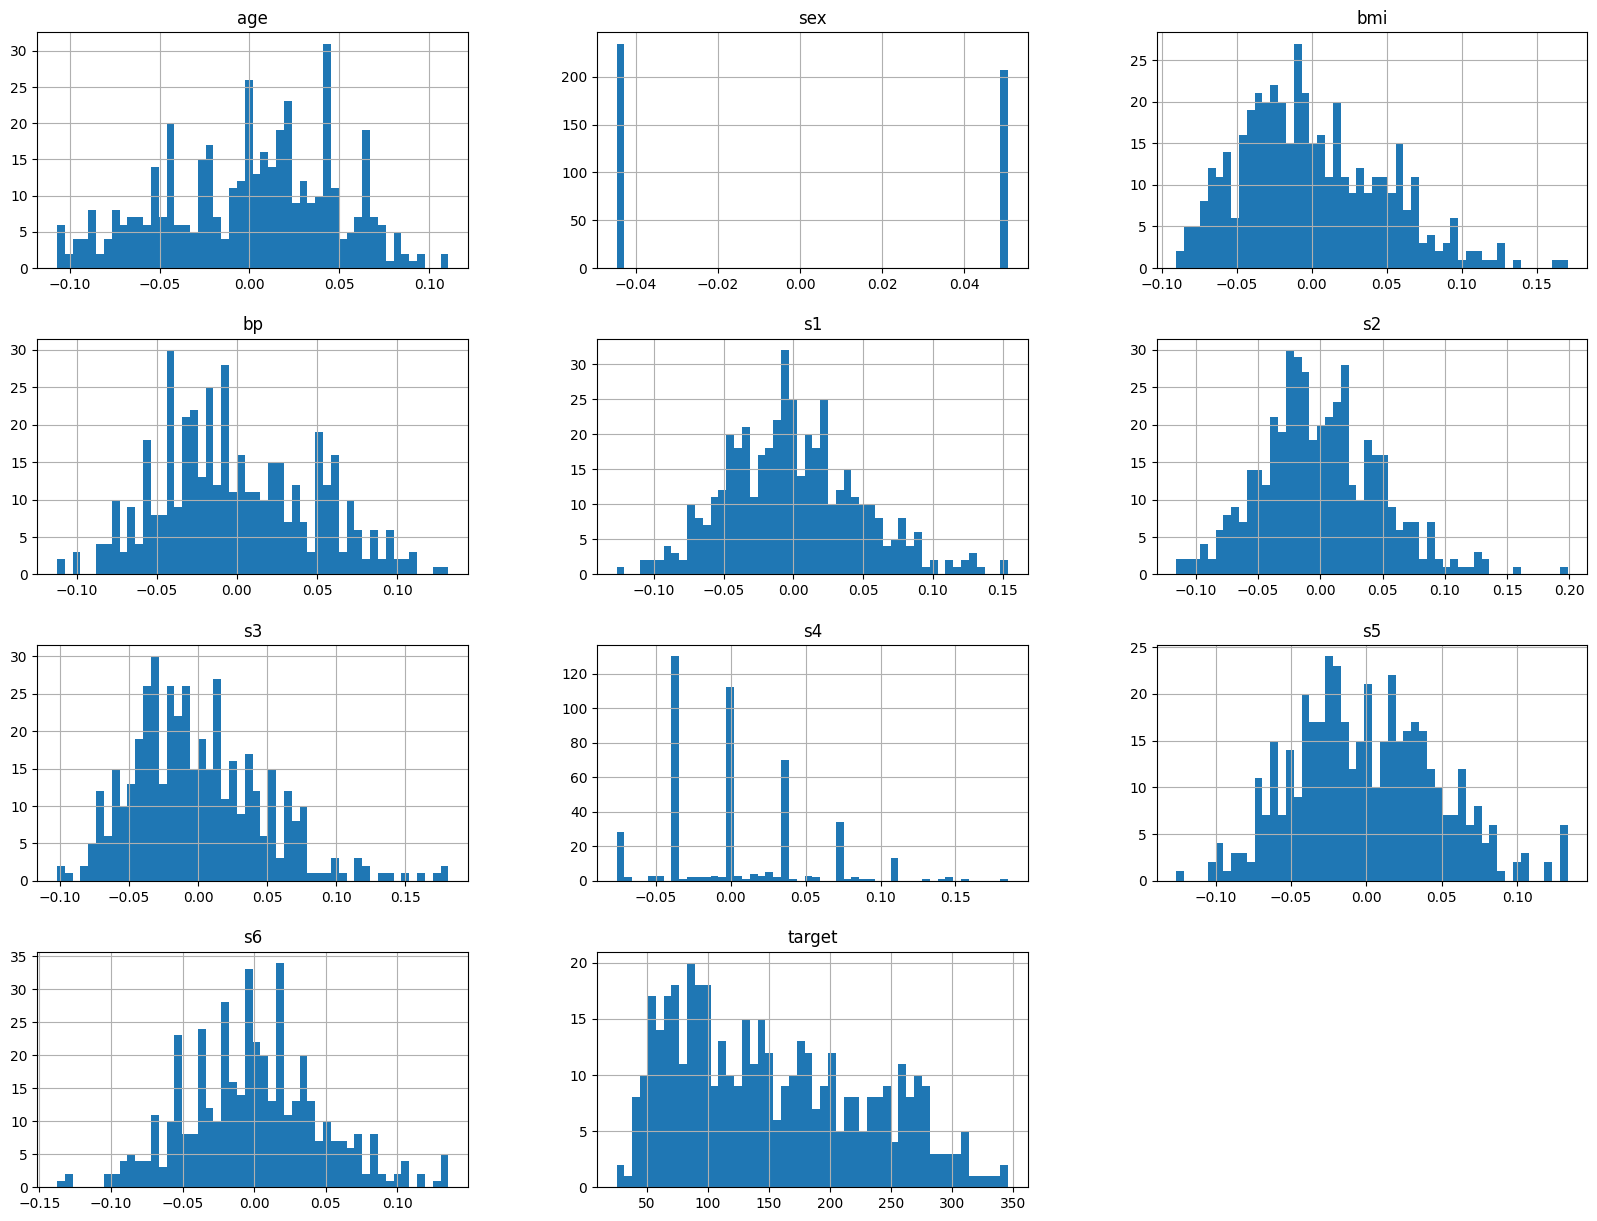

In [ ]:
import matplotlib.pyplot as plt
ddf.hist(bins=50, figsize=(20,15))
plt.show()

##Correlations

In [ ]:
import seaborn as sns

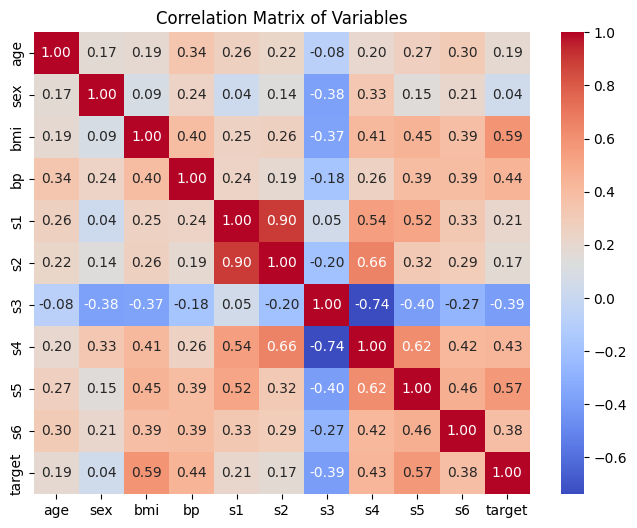

In [ ]:
# Compute correlation
corr = ddf.corr()

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Variables")
plt.show()

In [ ]:
ddf.isna().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


#Test Set

In [ ]:
ddf["bmic"] = pd.cut(ddf["bmi"], bins=[-0.1, -0.04, 0.02,
0.08, 0.14, 0.2], labels=[1, 2, 3, 4, 5])

<Axes: >

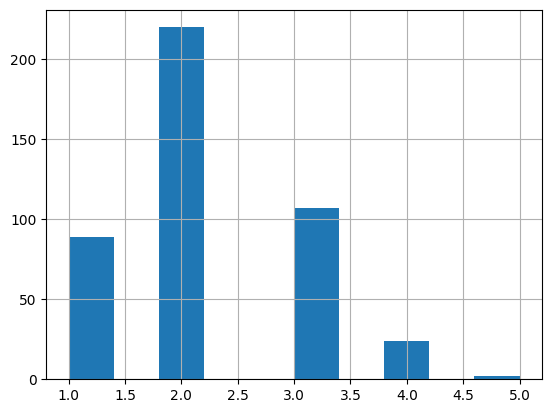

In [ ]:
ddf["bmic"].hist()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=72)
for train_index, test_index in split.split(ddf, ddf["bmic"]):
  strat_train_set = ddf.loc[train_index]
  strat_test_set = ddf.loc[test_index]

<Axes: >

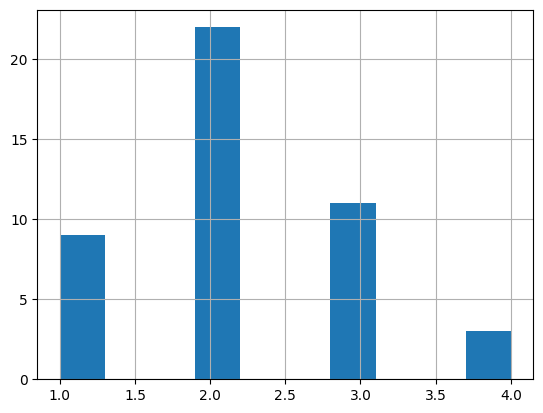

In [ ]:
strat_test_set["bmic"].hist()

In [ ]:
(ddf["bmic"] > 4).sum()

np.int64(2)

In [ ]:
strat_train_set.drop(columns="bmic", inplace=True)
strat_test_set.drop(columns="bmic", inplace=True)

#Training

In [ ]:
diabetes_features = strat_train_set.drop("target", axis=1)
diabetes_labels = strat_train_set["target"].copy()

In [ ]:
test_features = strat_test_set.drop("target", axis=1)
test_labels = strat_test_set["target"].copy()

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

##Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(diabetes_features, diabetes_labels)

LinearRegression()

In [ ]:
print("Predictions:", lin_reg.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

Predictions: [177.57241144 132.87758813 162.49352383 109.38001225  84.97944699
  55.11956047 233.80632574 170.42321055 119.67259233 231.64408008]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions = lin_reg.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(47.83271584303139)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

0.5984365203922555

##Ridge regression(with L2)

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=0.003)  # alpha is the regularization strength

# Step 3: Fit the model on the training data
ridge_model.fit(diabetes_features, diabetes_labels)

Ridge(alpha=0.003)

In [ ]:
print("Predictions:", ridge_model.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

Predictions: [177.59658992 133.26763709 163.48322809 109.5256094   84.7353018
  52.79965742 232.57259744 170.14953567 119.34128251 232.30239124]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions = ridge_model.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(47.755512839153035)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

0.5997317380049095

##Polynomial regression- Degree 3 & 5

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [ ]:
# Step 2: Create a pipeline with PolynomialFeatures + LinearRegression
degree = 5  # You can try 2, 3, etc.
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Step 3: Fit the model
poly_model.fit(diabetes_features, diabetes_labels)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=5)),
                ('linearregression', LinearRegression())])

In [ ]:
print("Predictions:", poly_model.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

Predictions: [  64.33520747  110.19967225 -209.95298236  123.11636842  251.79721993
 1329.8544932   125.36386837  221.78371153  140.70687063 1985.21616286]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions =poly_model.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(403.5664202825458)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

-27.58473524363415

##Non-linear: SVR

In [ ]:
from sklearn.svm import SVR

In [ ]:
# Step 2: Create a pipeline with scaling and SVR
svr_model = make_pipeline(
    SVR(kernel='poly', C=1.0, epsilon=0.1)
)

# Step 3: Fit the model
svr_model.fit(diabetes_features, diabetes_labels)

Pipeline(steps=[('svr', SVR(kernel='poly'))])

In [ ]:
print("Predictions:", svr_model.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

Predictions: [150.25223106 136.48887359 139.87818664 138.48039204 128.01987857
  61.13832759 163.31686319 145.34202323 132.50526215 201.81014252]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions = svr_model.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(62.68898749145834)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

0.31025805094773773

##Ensemble: Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Step 2: Create and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=72)
rf_model.fit(diabetes_features, diabetes_labels)

RandomForestRegressor(random_state=72)

In [ ]:
print("Predictions:", rf_model.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

Predictions: [189.8  120.76 127.55 144.21  86.87 123.61 231.71 193.01  96.08 209.91]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions = rf_model.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(52.44771326441856)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

0.5172111359898435

##XGBoost (eXtreme Gradient Boosting)

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(objective='reg:squarederror', max_depth=2, n_estimators=100, random_state=72)
xgb_model.fit(diabetes_features, diabetes_labels)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=72, ...)

In [ ]:
print("Predictions:", xgb_model.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

Predictions: [219.81497 116.24539 144.54294 123.8498   58.12865  40.9466  217.30864
 197.85837  89.92999 250.88383]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions = xgb_model.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(51.679655970904705)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

0.531247759217581

##MLP regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # Two layers: 64 and 32 neurons
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=72
)

mlp_model.fit(diabetes_features, diabetes_labels)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=72)

In [ ]:
print("Predictions:", mlp_model.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

Predictions: [173.40386514 137.42991068 146.57508491 119.58135839 103.24611914
  62.34263286 217.19327796 175.48798496 114.3642343  251.98362422]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions = mlp_model.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(49.746142681456554)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

0.5656668763703059

##Neural network

In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
# 3. Build the model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[diabetes_features.shape[1]]),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer for regression
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 4. Compile the model
model.compile(optimizer='adam', loss='mse')

In [ ]:
# 5. Train the model
history = model.fit(
    diabetes_features, diabetes_labels,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 30927.6211 - val_loss: 27114.5742
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 31384.2129 - val_loss: 27063.0898
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 30393.2402 - val_loss: 26982.4629
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 30271.4727 - val_loss: 26854.1836
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 28378.1016 - val_loss: 26654.8633
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 28805.0234 - val_loss: 26356.9883
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 29083.1426 - val_loss: 25947.2012
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 28050.9902 - val_loss: 25396.0039
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 28397.8340 - val_loss: 24696.9863
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 25697.5176 - val_loss: 23818.7617
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss

In [ ]:
print("Predictions:", model.predict(test_features.iloc[:10]))
print("Labels:", list(test_labels.iloc[:10]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predictions: [[176.84003 ]
 [137.20462 ]
 [154.08124 ]
 [117.23669 ]
 [ 96.86019 ]
 [ 51.13722 ]
 [226.5924  ]
 [178.50485 ]
 [113.847404]
 [252.125   ]]
Labels: [262.0, 67.0, 141.0, 69.0, 42.0, 57.0, 232.0, 122.0, 59.0, 281.0]


In [ ]:
predictions = model.predict(test_features)
lin_mse = mean_squared_error(test_labels, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


np.float64(49.11020879497823)

In [ ]:
r2 = r2_score(test_labels, predictions)
r2

0.5767005637350012

##Ridge Regression with CV

In [ ]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 13), scoring='r2')
ridge.fit(diabetes_features, diabetes_labels)
print("Best alpha:", ridge.alpha_)

Best alpha: 0.0031622776601683794


#Conclusion

| Model                  | Linear/Non-linear          | RMSE   | R²     |
|------------------------|----------------------------|--------|--------|
| Linear Regression      | Linear                     | 47.83  | 0.598  |
| Ridge Regression       | Linear                     | 52.79  | 0.51   |
| RidgeCV                | Linear                     | 47.75  | 0.599  |
| Polynomial (deg=3)     | Non-linear                 |435.84  |-32.34  |
| Polynomial (deg=5)     | Non-linear                 |403.56  |-27.58  |
| SVR                    | Non-linear                 | 62.69  | 0.31   |
| Random Forest Regressor| Non-linear                 | 52.45  | 0.52   |
| XGBoost Regressor      | Non-linear                 | 56.97  | 0.43   |
| XGBoost (optimal alpha)| Non-linear                 | 51.68  | 0.53   |
| MLP Regressor          | Non-linear                 | 49.75  | 0.56   |
| Neural Network (custom)| Non-linear                 | 49.11  | 0.58   |
